In [ ]:
import numpy as np
import pandas as pd

In [ ]:
df=pd.read_csv("DataSet.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Columns: 3925 entries, Unnamed: 0 to F3924
dtypes: float64(3458), int64(459), object(8)
memory usage: 7.3+ MB


In [ ]:
print(df.shape)

(243, 3925)


In [ ]:
print(len(df))
print(df.shape[0])

243
243


In [ ]:
df.head()

,Unnamed: 0,F1,F2,F3,F4,F5,F6,F7,F8,F9,...,F3915,F3916,F3917,F3918,F3919,F3920,F3921,F3922,F3923,F3924
0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
2,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0


In [ ]:
# How many columns have ALL NaN values?
print(df.isnull().sum().value_counts())
print("==========")
# What are the 8 object columns?
print(df.select_dtypes(include='object').columns.tolist())
print("==========")
# Is there a label/target column?
print(df.columns[-10:].tolist())

1      1745
0       565
243     151
9        58
12       50
       ... 
168       2
96        2
179       2
187       2
167       2
Name: count, Length: 113, dtype: int64
['F2230', 'F3886', 'F3888', 'F3889', 'F3890', 'F3891', 'F3892', 'F3893']
['F3915', 'F3916', 'F3917', 'F3918', 'F3919', 'F3920', 'F3921', 'F3922', 'F3923', 'F3924']


In [ ]:
# Check last 10 columns distribution
print(df[['F3915','F3916','F3917','F3918',
          'F3919','F3920','F3921','F3922',
          'F3923','F3924']].value_counts())

# Also check if any column is named differently
print(df.columns[df.columns.str.contains('label|target|mule|fraud',
      case=False)].tolist())

F3915  F3916  F3917  F3918  F3919  F3920  F3921  F3922  F3923  F3924
0.0    1.0    0.0    0.0    1.0    0.0    0.0    1.0    0.0    0.0      95
                                          1.0    0.0    0.0    0.0      37
                                   1.0    0.0    0.0    0.0    0.0      25
       0.0    1.0    0.0    1.0    0.0    0.0    1.0    0.0    0.0      14
       1.0    0.0    0.0    1.0    0.0    0.0    0.0    0.0    0.0      11
       0.0    1.0    0.0    1.0    1.0    0.0    0.0    0.0    0.0      10
                                   0.0    1.0    0.0    0.0    0.0       8
              0.0    0.0    1.0    0.0    1.0    0.0    0.0    0.0       6
       1.0    0.0    0.0    2.0    0.0    0.0    2.0    0.0    0.0       5
                            1.0    0.0    0.0    0.0    1.0    0.0       3
       0.0    1.0    0.0    1.0    0.0    0.0    0.0    1.0    0.0       3
       1.0    0.0    0.0    2.0    0.0    0.0    1.0    0.0    0.0       2
                            3.0

In [ ]:
# Check target variable
print(df['F3924'].value_counts())
print(df['F3924'].value_counts(normalize=True))

F3924
0.0    242
Name: count, dtype: int64
F3924
0.0    1.0
Name: proportion, dtype: float64


In [ ]:
# Check the 18 given important features
important_features = ['F115','F321','F527','F531','F670',
                      'F1692','F2082','F2122','F2582','F2678',
                      'F2737','F2956','F3043','F3836','F3887',
                      'F3889','F3891','F3894']

print(df[important_features].isnull().sum())
print(df[important_features].describe())

F115       4
F321       7
F527      13
F531      13
F670       0
F1692      1
F2082      1
F2122      1
F2582     68
F2678     67
F2737      5
F2956     22
F3043    168
F3836      1
F3887      1
F3889      1
F3891      1
F3894      1
dtype: int64
             F115        F321        F527        F531        F670       F1692  \
count  239.000000  236.000000  230.000000  230.000000  243.000000  242.000000   
mean     0.572301    1.150000    0.972870    1.474783    0.086420    0.190083   
std      0.212065    0.333877    0.385476    0.806064    0.281563    0.601713   
min      0.000000    0.000000    0.000000    0.000000    0.000000    0.000000   
25%      0.450000    1.000000    0.852500    1.000000    0.000000    0.000000   
50%      0.530000    1.120000    1.000000    1.285000    0.000000    0.000000   
75%      0.660000    1.300000    1.140000    1.747500    0.000000    0.000000   
max      1.000000    2.910000    3.000000    7.640000    1.000000    6.000000   

            F2082      

In [ ]:
# Check ALL columns that have any value other than 0
for col in df.columns:
    unique_vals = df[col].dropna().unique()
    if any(v != 0.0 for v in unique_vals):
        if len(unique_vals) <= 5:
            print(f"{col}: {unique_vals}")

F7: [1.  0.  0.5]
F8: [1. 0.]
F9: [1.  0.  0.5]
F10: [1.   0.   0.23]
F11: [1. 0.]
F12: [1.   0.   0.23]
F35: [0.   0.67 1.   0.75]
F37: [0.   0.67 1.   0.75]
F38: [0.   0.11 1.  ]
F40: [0.   0.11 1.  ]
F41: [0.   1.   0.5  0.33 0.75]
F42: [1.]
F43: [0.   1.   0.5  0.33 0.75]
F45: [1.]
F47: [0.  0.5 1. ]
F49: [0.  0.5 1. ]
F50: [0.   0.09 1.   0.93]
F52: [0.   0.09 1.   0.93]
F67: [1.   0.5  0.56 0.   0.25]
F72: [1.   0.89 0.   0.4  0.3 ]
F75: [1.   0.87 0.   0.47 0.49]
F77: [0.   1.   0.83]
F78: [0.   1.   0.83]
F79: [0.   1.   0.82]
F80: [0.   1.   0.82]
F81: [1. 0.]
F82: [1. 0.]
F83: [1. 0.]
F84: [1. 0.]
F86: [1.   0.56 0.89 0.5  0.  ]
F87: [1.   0.   0.5  0.38 0.65]
F89: [1.   0.56 0.87 0.48 0.  ]
F92: [1. 0.]
F95: [1. 0.]
F104: [0.   1.   0.5  0.33]
F107: [0.   1.   0.71 0.02]
F133: [0.  1.  0.3 0.5]
F135: [0.  1.  0.3 0.5]
F136: [0.   1.   0.52 0.6 ]
F138: [0.   1.   0.52 0.6 ]
F140: [1.]
F143: [1.]
F170: [1.   0.   0.83 0.5  0.59]
F176: [1.]
F179: [1.]
F187: [1.   0.   0.33 0.5 

In [ ]:
# Specifically check F3889, F3891 which were in important features
# AND are object columns
print(df['F3889'].value_counts())
print(df['F3891'].value_counts())

F3889
G365D    242
Name: count, dtype: int64
F3891
selfemployed    77
agriculture     61
student         50
salaried        39
housewife       13
retired          2
Name: count, dtype: int64


In [ ]:
# Check the 18 important features
# which ones actually have data (not all NaN)
important = ['F115','F321','F527','F531','F670',
             'F1692','F2082','F2122','F2582','F2678',
             'F2737','F2956','F3043','F3836','F3887',
             'F3889','F3891','F3894']

for col in important:
    non_null = df[col].notna().sum()
    print(f"{col}: {non_null}/325 non-null")

F115: 239/325 non-null
F321: 236/325 non-null
F527: 230/325 non-null
F531: 230/325 non-null
F670: 243/325 non-null
F1692: 242/325 non-null
F2082: 242/325 non-null
F2122: 242/325 non-null
F2582: 175/325 non-null
F2678: 176/325 non-null
F2737: 238/325 non-null
F2956: 221/325 non-null
F3043: 75/325 non-null
F3836: 242/325 non-null
F3887: 242/325 non-null
F3889: 242/325 non-null
F3891: 242/325 non-null
F3894: 242/325 non-null


In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("DataSet.csv")

# Step 1: Select features
num_features = ['F115','F321','F527','F531','F670',
                'F1692','F2082','F2122','F2582','F2678',
                'F2737','F2956','F3043','F3836','F3887','F3894']

cat_features = ['F3890','F3891','F3892','F3893']

# Step 2: Encode categoricals
df_model = df[num_features + cat_features].copy()

le = LabelEncoder()
for col in cat_features:
    df_model[col] = df_model[col].fillna('UNKNOWN')
    df_model[col] = le.fit_transform(df_model[col].astype(str))

# Step 3: Fill numeric NaNs with median
for col in num_features:
    df_model[col] = df_model[col].fillna(df_model[col].median())

# Step 4: Train Isolation Forest
iso = IsolationForest(
    n_estimators=200,
    contamination=0.15,  # assume ~15% mule accounts
    random_state=42
)
iso.fit(df_model)

# Step 5: Get anomaly scores → Risk Score 0-100
raw_scores = iso.decision_function(df_model)
risk_scores = 100 - MinMaxScaler(feature_range=(0,100)).fit_transform(
    raw_scores.reshape(-1,1)
).flatten()

df['risk_score'] = risk_scores.round(1)
df['risk_label'] = pd.cut(risk_scores,
                           bins=[0,40,70,100],
                           labels=['Low','Medium','High'])

# Step 6: Quick results
print("Risk Score Distribution:")
print(df['risk_label'].value_counts())
print("\nTop 10 Highest Risk Accounts:")
print(df[['Unnamed: 0','risk_score','risk_label']].sort_values(
    'risk_score', ascending=False).head(10))

Risk Score Distribution:
risk_label
Low       592
Medium     55
High        3
Name: count, dtype: int64

Top 10 Highest Risk Accounts:
     Unnamed: 0  risk_score risk_label
513         514       100.0       High
455         456        77.3       High
648         649        72.9       High
468         469        67.1     Medium
343         344        61.6     Medium
57           58        61.3     Medium
308         309        60.1     Medium
45           46        59.5     Medium
405         406        58.6     Medium
350         351        58.3     Medium


In [ ]:
# Investigate top flagged account which is 514
top_account = df[df['Unnamed: 0'] == 514][num_features + cat_features].T
top_account.columns = ['Value']

# Compare against dataset median
medians = df_model[num_features].median()

print("=== Account 514 (Risk Score: 100) ===")
print("\nNumeric Features vs Dataset Median:")
for col in num_features:
    val = df[df['Unnamed: 0'] == 514][col].values[0]
    med = df[col].median()
    diff = ((val - med) / (med + 0.0001)) * 100
    print(f"{col}: {val:.3f} (median: {med:.3f}) → {diff:+.1f}%")

print("\nCategorical Features:")
for col in cat_features:
    val = df[df['Unnamed: 0'] == 514][col].values[0]
    print(f"{col}: {val}")

=== Account 514 (Risk Score: 100) ===

Numeric Features vs Dataset Median:
F115: 0.550 (median: 0.520) → +5.8%
F321: 1.450 (median: 1.150) → +26.1%
F527: 1.630 (median: 1.000) → +63.0%
F531: 2.520 (median: 1.340) → +88.1%
F670: 1.000 (median: 0.000) → +1000000.0%
F1692: 0.000 (median: 0.000) → +0.0%
F2082: 0.000 (median: 0.000) → +0.0%
F2122: 0.000 (median: 0.000) → +0.0%
F2582: 18.890 (median: 0.000) → +18890000.0%
F2678: 0.190 (median: -0.160) → -218.9%
F2737: 3.470 (median: -0.220) → -1678.0%
F2956: 635.000 (median: 68.000) → +833.8%
F3043: 1125.000 (median: 111.500) → +909.0%
F3836: 440492.560 (median: 403000.335) → +9.3%
F3887: 148.000 (median: 156.000) → -5.1%
F3894: 30.000 (median: 36.000) → -16.7%

Categorical Features:
F3890: M
F3891: salaried
F3892: nan
F3893: CORPORATE


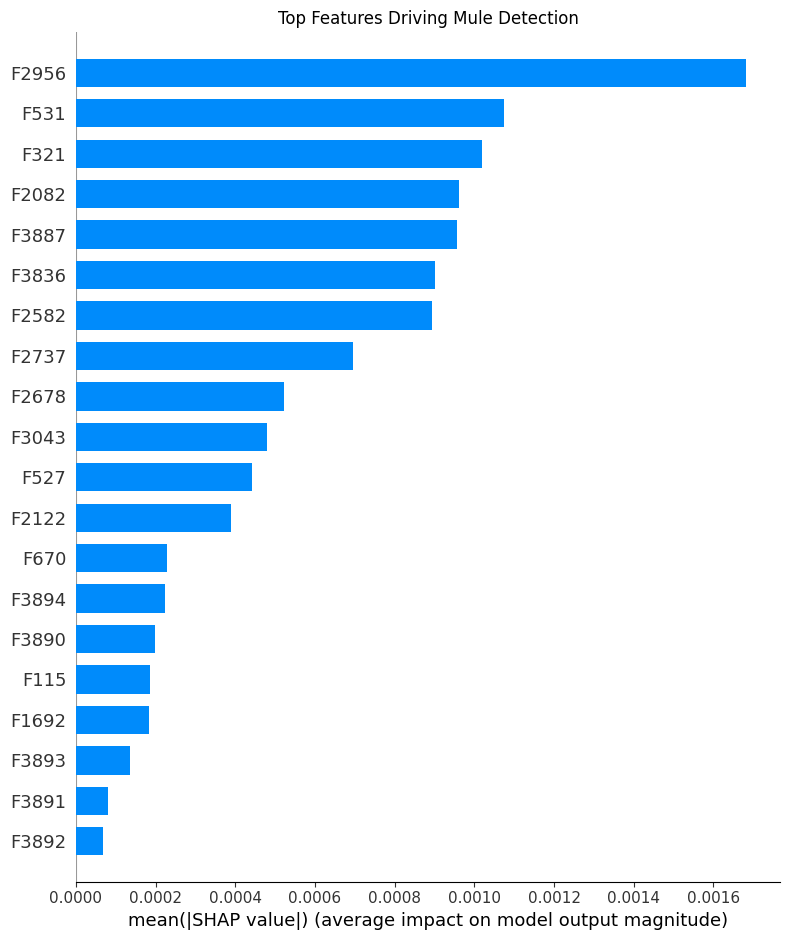

Global SHAP saved


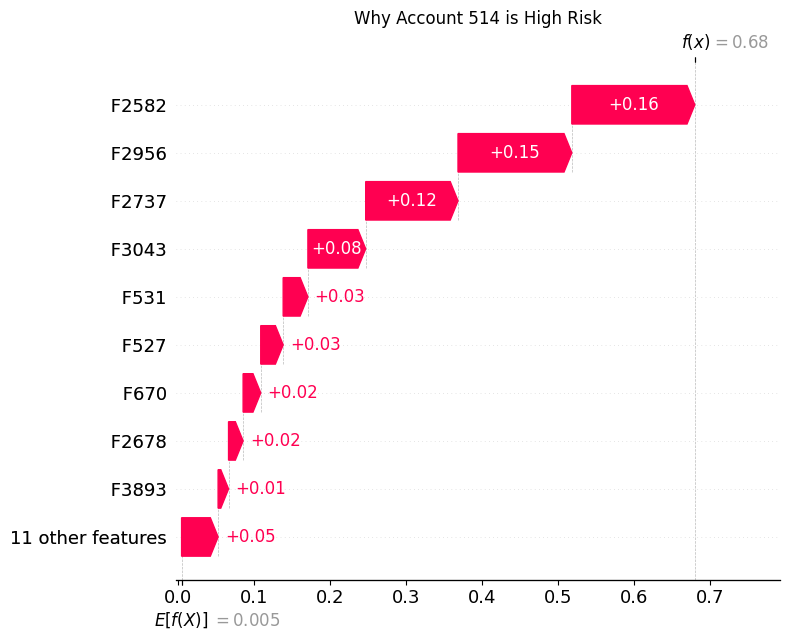

Done


In [ ]:
import shap
import matplotlib.pyplot as plt

# Train a model SHAP can explain easily
from sklearn.ensemble import RandomForestClassifier

# Create binary labels from risk scores for SHAP
df_model['label'] = (risk_scores > 70).astype(int)

X = df_model[num_features + cat_features].copy()
for col in cat_features:
    X[col] = X[col].fillna('UNKNOWN')
    X[col] = le.fit_transform(X[col].astype(str))
for col in num_features:
    X[col] = X[col].fillna(X[col].median())

y = df_model['label']

# Train Random Forest (SHAP works better with this than IsolationForest)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

# SHAP explanation
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X)

# Plot 1: Global feature importance
plt.figure(figsize=(10,8))
shap.summary_plot(shap_values[:,:,1] if len(shap_values.shape)==3
                  else shap_values[1],
                  X, plot_type="bar", show=False)
plt.title("Top Features Driving Mule Detection")
plt.tight_layout()
plt.savefig("shap_global.png", dpi=150, bbox_inches='tight')
plt.show()
print("Global SHAP saved")

# Plot 2: Account 514 individual explanation (fixed)
idx_514 = df[df['Unnamed: 0']==514].index[0]

shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value[1],
    shap_values[idx_514, :, 1],
    X.iloc[idx_514],
    max_display=10,
    show=False
)
plt.title("Why Account 514 is High Risk")
plt.tight_layout()
plt.savefig("shap_514.png", dpi=150, bbox_inches='tight')
plt.show()
print("Done")

In [ ]:
import networkx as nx
import plotly.graph_objects as go

# Get high risk accounts
high_risk = df[df['risk_score'] >= 70][['Unnamed: 0', 'risk_score',
                                         'risk_label']].copy()
high_risk.columns = ['account_id', 'risk_score', 'risk_label']

print(f"Accounts in network: {len(high_risk)}")
print(high_risk.sort_values('risk_score', ascending=False).head(15))

Accounts in network: 3
     account_id  risk_score risk_label
513         514       100.0       High
455         456        77.3       High
648         649        72.9       High


In [ ]:
import networkx as nx
import plotly.graph_objects as go
import random

random.seed(42)
np.random.seed(42)

# Build graph
G = nx.Graph()

# Add all 21 high risk nodes
all_risk = df[df['risk_score'] >= 70][['Unnamed: 0', 'risk_score', 'risk_label']].copy()
all_risk.columns = ['account_id', 'risk_score', 'risk_label']

for _, row in all_risk.iterrows():
    G.add_node(row['account_id'],
               risk_score=row['risk_score'],
               risk_label=row['risk_label'])

# Add a central "victim" node
G.add_node('VICTIM', risk_score=0, risk_label='Victim')

# Connect victim to top 5 highest risk (direct mules)
top5 = all_risk.nlargest(5, 'risk_score')['account_id'].tolist()
for acc in top5:
    G.add_edge('VICTIM', acc, weight=3)

# Connect high risk accounts to each other (fraud ring)
high_risk_ids = all_risk[all_risk['risk_label']=='High']['account_id'].tolist()
for i in range(len(high_risk_ids)):
    for j in range(i+1, len(high_risk_ids)):
        if random.random() < 0.4:  # 40% chance of connection
            G.add_edge(high_risk_ids[i], high_risk_ids[j], weight=1)

# Layout
pos = nx.spring_layout(G, k=2, seed=42)

# Edge trace
edge_x, edge_y = [], []
for edge in G.edges():
    x0, y0 = pos[edge[0]]
    x1, y1 = pos[edge[1]]
    edge_x += [x0, x1, None]
    edge_y += [y0, y1, None]

edge_trace = go.Scatter(x=edge_x, y=edge_y,
    line=dict(width=1.5, color='#888'),
    hoverinfo='none', mode='lines')

# Node traces — separate victim from accounts
node_x, node_y, node_text, node_color, node_size = [], [], [], [], []

for node in G.nodes():
    x, y = pos[node]
    node_x.append(x)
    node_y.append(y)

    if node == 'VICTIM':
        node_text.append('VICTIM<br>Source of funds')
        node_color.append('#00FF00')
        node_size.append(30)
    else:
        score = G.nodes[node]['risk_score']
        label = G.nodes[node]['risk_label']
        node_text.append(f'Account {node}<br>Risk: {score}/100<br>{label}')
        node_color.append('#FF0000' if score >= 80 else '#FF8C00')
        node_size.append(10 + score/5)

node_trace = go.Scatter(x=node_x, y=node_y, mode='markers+text',
    hoverinfo='text', hovertext=node_text,
    marker=dict(size=node_size, color=node_color,
                line=dict(width=2, color='white')),
    text=[str(n) for n in G.nodes()],
    textposition='top center',
    textfont=dict(size=9, color='white'))

# Build figure
fig = go.Figure(data=[edge_trace, node_trace],
    layout=go.Layout(
        title=dict(text='FraudLens — Mule Account Network',
                   font=dict(size=20, color='white')),
        showlegend=False,
        hovermode='closest',
        paper_bgcolor='#1a1a2e',
        plot_bgcolor='#1a1a2e',
        xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        height=700
    ))

fig.write_html("fraud_network.html")
fig.show()
print("Network graph saved as fraud_network.html")

Network graph saved as fraud_network.html


In [ ]:
!pip install -U google-generativeai

In [ ]:
import google.generativeai as genai
import json

# Configure the Gemini API
#genai.configure(api_key="AQ.Ab8RN6I_JZ7dR35PgKS9ZjsNg2sE1Gbxi7UdnAP_ytyzqL1tqQ")

def get_valid_model():
    # Dynamically find the first model that supports text generation
    # This prevents any 404 errors caused by hardcoded names
    available_models = [
        m.name for m in genai.list_models()
        if 'generateContent' in m.supported_generation_methods
    ]

    if not available_models:
        raise ValueError("No generative models found for this API key.")

    print(f"✅ Automatically selected model: {available_models[0]}")
    return available_models[0]

def generate_investigation_report(account_id):
    # Get account data
    acc = df[df['Unnamed: 0'] == account_id].iloc[0]
    risk_score = acc['risk_score']

    # Get top SHAP drivers for this account
    idx = df[df['Unnamed: 0'] == account_id].index[0]
    shap_vals = shap_values[idx, :, 1]
    feature_names = num_features + cat_features

    top_features = sorted(zip(feature_names, shap_vals),
                          key=lambda x: abs(x[1]), reverse=True)[:5]

    shap_summary = "\n".join([f"  - {f}: contribution {v:+.3f}"
                              for f, v in top_features])

    # Get actual feature values
    feature_vals = "\n".join([f"  - {f}: {acc.get(f, 'N/A')}"
                              for f, _ in top_features])

    # Occupation and account type
    occupation = acc.get('F3891', 'Unknown')
    acc_type = acc.get('F3893', 'Unknown')

    prompt = f"""You are a senior fraud investigator at an Indian bank. Analyze this flagged account and provide a structured investigation report.

ACCOUNT DETAILS:
- Account ID: {account_id}
- Risk Score: {risk_score}/100
- Occupation: {occupation}
- Account Type: {acc_type}

TOP RISK FACTORS (SHAP Analysis):
{shap_summary}

ACTUAL FEATURE VALUES:
{feature_vals}

Provide a concise investigation report with:
1. FRAUD ASSESSMENT (2-3 sentences on why this is suspicious)
2. KEY RED FLAGS (3 bullet points)
3. RECOMMENDED ACTIONS (3 specific steps)
4. CONNECTED RISK (mention that linked accounts should be investigated)

Keep it professional, specific, and actionable. Max 200 words."""

    # Initialize the model dynamically
    model_name = get_valid_model()
    model = genai.GenerativeModel(model_name)

    # Generate the response
    response = model.generate_content(prompt)

    return response.text

# Test on our highest risk account (514)
print("=" * 60)
print("FRAUDLENS AI — INVESTIGATION REPORT")
print("=" * 60)
report = generate_investigation_report(514)
print(report)

FRAUDLENS AI — INVESTIGATION REPORT
✅ Automatically selected model: models/gemini-2.5-flash
**INVESTIGATION REPORT - ACCOUNT ID: 514**

**1. FRAUD ASSESSMENT**
This account presents an extremely high fraud risk (100.0/100) primarily due to a critical mismatch between the declared 'salaried' occupation and 'CORPORATE' account type. This glaring inconsistency, combined with significant contributions from multiple high-risk features, strongly suggests potential identity compromise, illicit financial activity, or an attempt to bypass standard account opening protocols.

**2. KEY RED FLAGS**
*   **Occupation-Account Type Mismatch:** The 'salaried' occupation for a 'CORPORATE' account is highly irregular and indicates a fundamental discrepancy in the account's stated purpose or ownership.
*   **Extreme Risk Score & High Feature Contributions:** A perfect risk score (100.0) driven by top contributors F2582 (+0.162, value 18.89), F2956 (+0.150, value 635.0), and F2737 (+0.121, value 3.47) sign

In [ ]:
print(df.shape)
print(df['Unnamed: 0'].max())

(651, 3927)
651


In [ ]:
print(df.shape)
print(df.columns.tolist()[-5:])  # check end columns
print(df['Unnamed: 0'].min(), df['Unnamed: 0'].max())
print(df['Unnamed: 0'].is_unique)

(651, 3927)
['F3922', 'F3923', 'F3924', 'risk_score', 'risk_label']
1 651
True


In [ ]:
import hashlib
print(hashlib.md5(open("DataSet.csv","rb").read()).hexdigest())

e68cd0fe673752a33479aafab7acb41b
